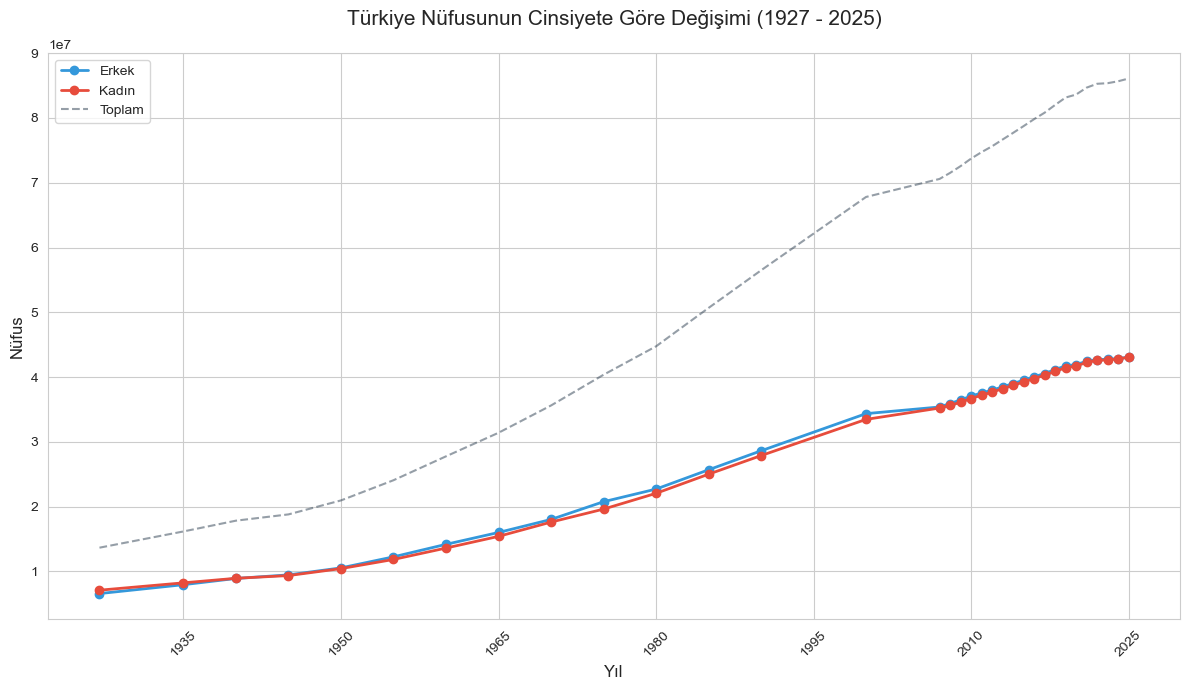

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# 1. Veriyi okuma ve temizleme
df = pd.read_csv('Cinsiyete Göre Nüfus.csv', encoding='iso-8859-9', sep=None, engine='python')

# Sütun isimlerini düzeltme
df.columns = ['Yıl', 'Düzey', 'Toplam', 'Erkek', 'Kadın', 'Not']
df = df.iloc[1:34].copy()

# Sayısal değerlere dönüştürme
for col in ['Toplam', 'Erkek', 'Kadın']:
    df[col] = df[col].str.replace('.', '', regex=False).astype(int)

df['Yıl'] = df['Yıl'].astype(int)

# Veriyi sıralama
df = df.sort_values('Yıl')

# Grafik
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

plt.plot(df['Yıl'], df['Erkek'], label='Erkek', marker='o', color='#3498db', linewidth=2)
plt.plot(df['Yıl'], df['Kadın'], label='Kadın', marker='o', color='#e74c3c', linewidth=2)
plt.plot(df['Yıl'], df['Toplam'], label='Toplam', linestyle='--', color='#2c3e50', alpha=0.5)

# Başlıklar
plt.title('Türkiye Nüfusunun Cinsiyete Göre Değişimi (1927 - 2025)', fontsize=15, pad=20)
plt.xlabel('Yıl', fontsize=12)
plt.ylabel('Nüfus', fontsize=12)

# X ekseni düzenleme
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

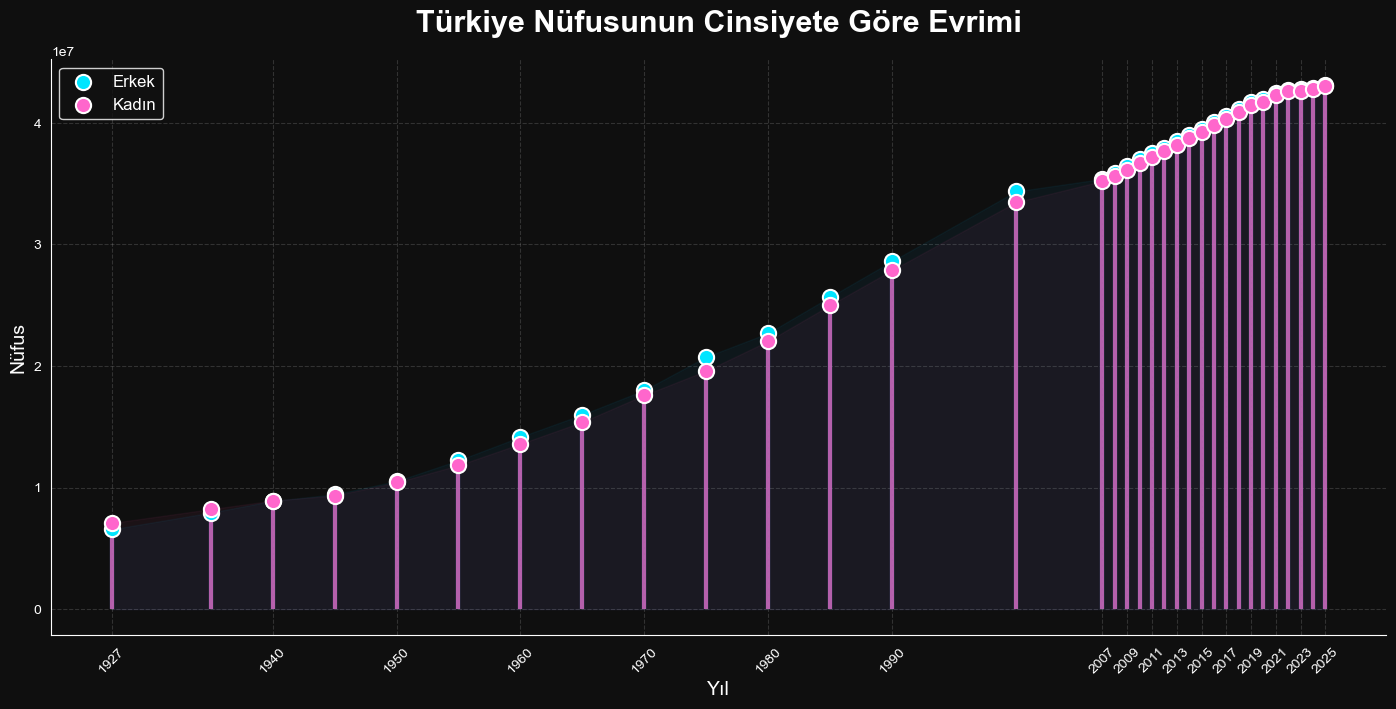

In [15]:
# MODERN LOLIPOP CHART (Tamamen farklı grafik)

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(15,8))

# Erkek çizgileri
ax.vlines(
    df_clean['Yıl'],
    ymin=0,
    ymax=df_clean['Erkek'],
    color='#00bfff',
    alpha=0.7,
    linewidth=3
)

# Erkek noktaları
ax.scatter(
    df_clean['Yıl'],
    df_clean['Erkek'],
    color='#00e5ff',
    s=120,
    edgecolors='white',
    linewidth=1.5,
    label='Erkek',
    zorder=3
)

# Kadın çizgileri
ax.vlines(
    df_clean['Yıl'],
    ymin=0,
    ymax=df_clean['Kadın'],
    color='#ff4da6',
    alpha=0.7,
    linewidth=3
)

# Kadın noktaları
ax.scatter(
    df_clean['Yıl'],
    df_clean['Kadın'],
    color='#ff66cc',
    s=120,
    edgecolors='white',
    linewidth=1.5,
    label='Kadın',
    zorder=3
)

# Gradient benzeri alan
ax.fill_between(
    df_clean['Yıl'],
    df_clean['Erkek'],
    alpha=0.05,
    color='#00bfff'
)

ax.fill_between(
    df_clean['Yıl'],
    df_clean['Kadın'],
    alpha=0.05,
    color='#ff4da6'
)

# Başlık
plt.title(
    'Türkiye Nüfusunun Cinsiyete Göre Evrimi',
    fontsize=22,
    fontweight='bold',
    pad=20,
    color='white'
)

# Eksenler
plt.xlabel('Yıl', fontsize=14)
plt.ylabel('Nüfus', fontsize=14)

# Grid
plt.grid(
    linestyle='--',
    alpha=0.15
)

# X ekseni
plt.xticks(
    df_clean['Yıl'][::2],
    rotation=45,
    fontsize=10
)

# Legend
plt.legend(
    facecolor='#111111',
    edgecolor='white',
    fontsize=12
)

# Kenarlıkları kaldır
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Arkaplan
ax.set_facecolor('#0f0f0f')
fig.patch.set_facecolor('#0f0f0f')

# Layout
plt.subplots_adjust(
    left=0.08,
    right=0.97,
    bottom=0.18,
    top=0.90
)

plt.show()

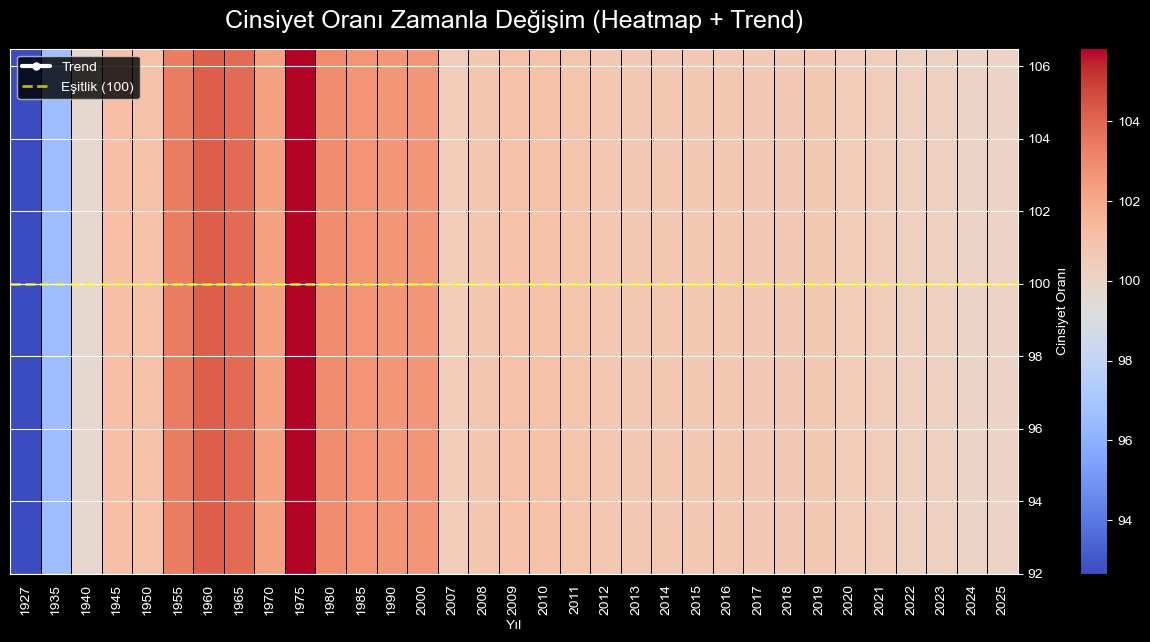

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# MODERN HEATMAP + TREND GRAFİĞİ

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14,7))

# Heatmap için veri hazırlama
heat_data = df_clean[['Yıl', 'Cinsiyet_Orani']].set_index('Yıl')

sns.heatmap(
    heat_data.T,
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
    linecolor='black',
    ax=ax
)

# Trend çizgisi (overlay)
ax2 = ax.twinx()

ax2.plot(
    df_clean['Yıl'],
    df_clean['Cinsiyet_Orani'],
    color='white',
    linewidth=3,
    marker='o',
    markersize=5,
    label='Trend'
)

# Referans çizgisi
ax2.axhline(
    100,
    color='yellow',
    linestyle='--',
    linewidth=2,
    alpha=0.7,
    label='Eşitlik (100)'
)

# Başlık
plt.title(
    'Cinsiyet Oranı Zamanla Değişim (Heatmap + Trend)',
    fontsize=18,
    pad=15
)

# Eksenler
ax.set_xlabel('Yıl')
ax.set_ylabel('')
ax.set_yticks([])

ax2.set_ylabel('Cinsiyet Oranı')

# Grid kapatma (heatmap zaten yeterli)
ax.grid(False)

# Legend
ax2.legend(loc='upper left')

# Layout
plt.subplots_adjust(
    left=0.05,
    right=0.95,
    bottom=0.15,
    top=0.90
)

plt.show()

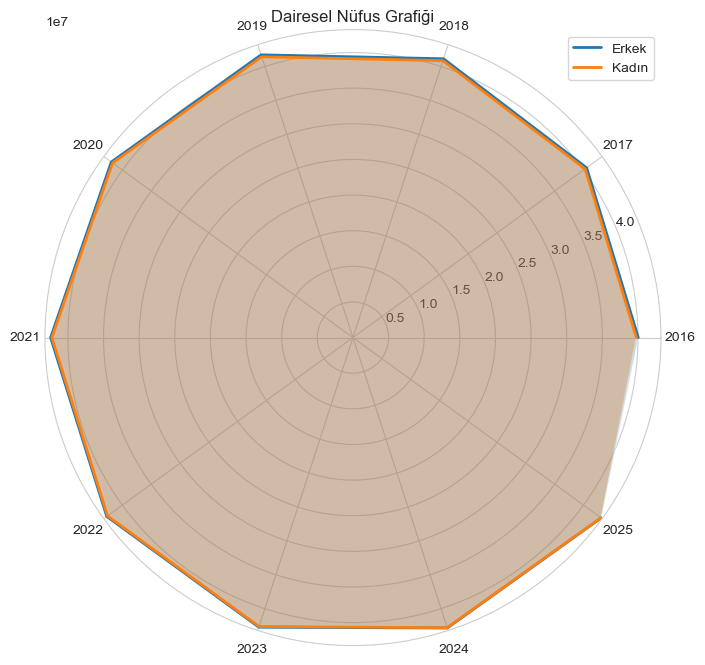

In [9]:
import numpy as np

last_10 = df_clean.tail(10)

angles = np.linspace(0, 2*np.pi, len(last_10), endpoint=False)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, last_10['Erkek'], label='Erkek', linewidth=2)
ax.fill(angles, last_10['Erkek'], alpha=0.3)

ax.plot(angles, last_10['Kadın'], label='Kadın', linewidth=2)
ax.fill(angles, last_10['Kadın'], alpha=0.3)

ax.set_xticks(angles)
ax.set_xticklabels(last_10['Yıl'])

plt.title('Dairesel Nüfus Grafiği')
plt.legend()

plt.show()

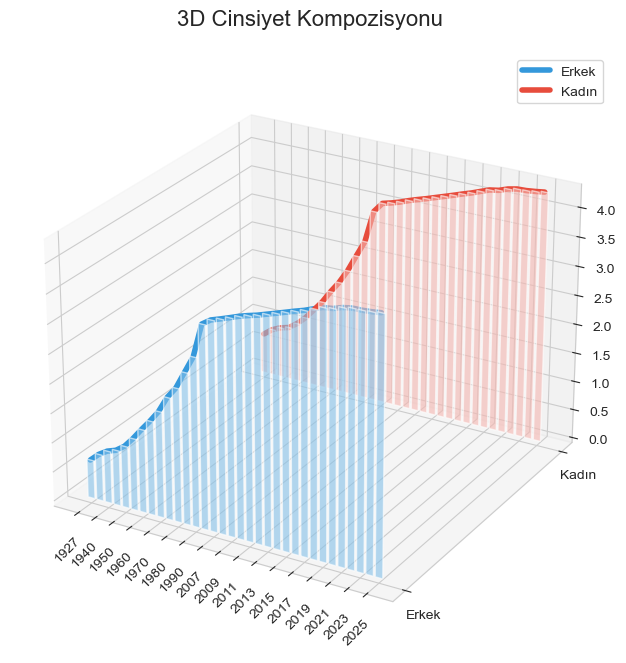

In [12]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# GRAFİK 4 - 3D CİNSİYET KOMPOZİSYONU

fig = plt.figure(figsize=(14,8))
ax = fig.add_subplot(111, projection='3d')

# X ekseni
x = np.arange(len(df_clean['Yıl']))

# Erkek çizgisi
ax.plot(
    x,
    np.zeros(len(x)),
    df_clean['Erkek'],
    color='#3498db',
    linewidth=4,
    label='Erkek'
)

# Kadın çizgisi
ax.plot(
    x,
    np.ones(len(x)),
    df_clean['Kadın'],
    color='#e74c3c',
    linewidth=4,
    label='Kadın'
)

# Erkek barları
ax.bar(
    x,
    df_clean['Erkek'],
    zs=0,
    zdir='y',
    alpha=0.6,
    color='#85c1e9'
)

# Kadın barları
ax.bar(
    x,
    df_clean['Kadın'],
    zs=1,
    zdir='y',
    alpha=0.6,
    color='#f5b7b1'
)

# X ekseni ayarları
ax.set_xticks(x[::2])
ax.set_xticklabels(df_clean['Yıl'][::2], rotation=45)

# Y ekseni ayarları
ax.set_yticks([0,1])
ax.set_yticklabels(['Erkek', 'Kadın'])

# Z ekseni
ax.set_zlabel('Nüfus')

# Başlık
ax.set_title(
    '3D Cinsiyet Kompozisyonu',
    fontsize=16,
    pad=20
)

# Kamera açısı
ax.view_init(elev=25, azim=-60)

# Layout düzeltme
plt.subplots_adjust(
    left=0.05,
    right=0.95,
    bottom=0.15,
    top=0.90
)

plt.legend()

plt.show()